# Project1 - Amazon Product Reviews Sentiment Analysis 

## Importing Libraries and Datasets
The libraries used are : 

Pandas : For importing the dataset.
Scikit-learn : For importing the model, accuracy module, and TfidfVectorizer.
Warning : To ignore all the warnings
Matplotlib : To plot the visualization. Also used Wordcloud for that.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

For NLP part, we will be using NLTK Library. From that we will be requiring stopword and punkt. so let's download and import them using the below command.

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


After that import the downloaded dataset using the below code.

In [3]:
import os
os.getcwd()

'C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP'

In [8]:
data = pd.read_csv(r"C:\\Users\\Saksh\\OneDrive\\Desktop\\FACEPREP JAN 2026 - JUNE 2026\\NLP\Amazon-Product-Reviews-Sentiment-Analysis-in-Python-Dataset.csv")
data.head()

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1


## Preprocessing and cleaning the reviews 

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


Now, To drop the null values (if any), run the below command.

In [10]:
data.dropna(inplace=True)

To predict the Sentiment as positive(numerical value = 1) or negative(numerical value = 0), we need to change them the values to those categories. For that the condition will be like if the sentiment value is less than or equal to 3, then it is negative(0) else positive(1). For better understanding, refer the code below.

In [11]:
#1,2,3->negative(i.e 0)
data.loc[data['Sentiment']<=3,'Sentiment'] = 0

#4,5->positive(i.e 1)
data.loc[data['Sentiment']>3,'Sentiment'] = 1

Now, once the dataset is ready, we will clean the review column by removing the stopwords. The code for that is given below.

In [12]:
stp_words=stopwords.words('english')
def clean_review(review): 
  cleanreview=" ".join(word for word in review.
                       split() if word not in stp_words)
  return cleanreview 

data['Review']=data['Review'].apply(clean_review)

Once we have done with the preprocess. Let's see the top 5 rows to see the improved dataset.

In [13]:
data.head()

,Review,Sentiment
0,Fast shipping product cheaply made I brought g...,0
1,This case takes long ship even worth DONT BUY!!!!,0
2,Good droids. Not good iPhones. You cannot use ...,0
3,The cable compatible macbook iphone. Also conn...,0
4,The case nice glow light. I'm disappointed pro...,0


Analysis of the Dataset
Let's check out that how many counts are there for positive and negative sentiments.

In [14]:
data['Sentiment'].value_counts()

Sentiment
0    15000
1     9999
Name: count, dtype: int64

To have the better picture of the importance of the words let's create the Wordcloud of all the words with sentiment = 0 i.e. negative

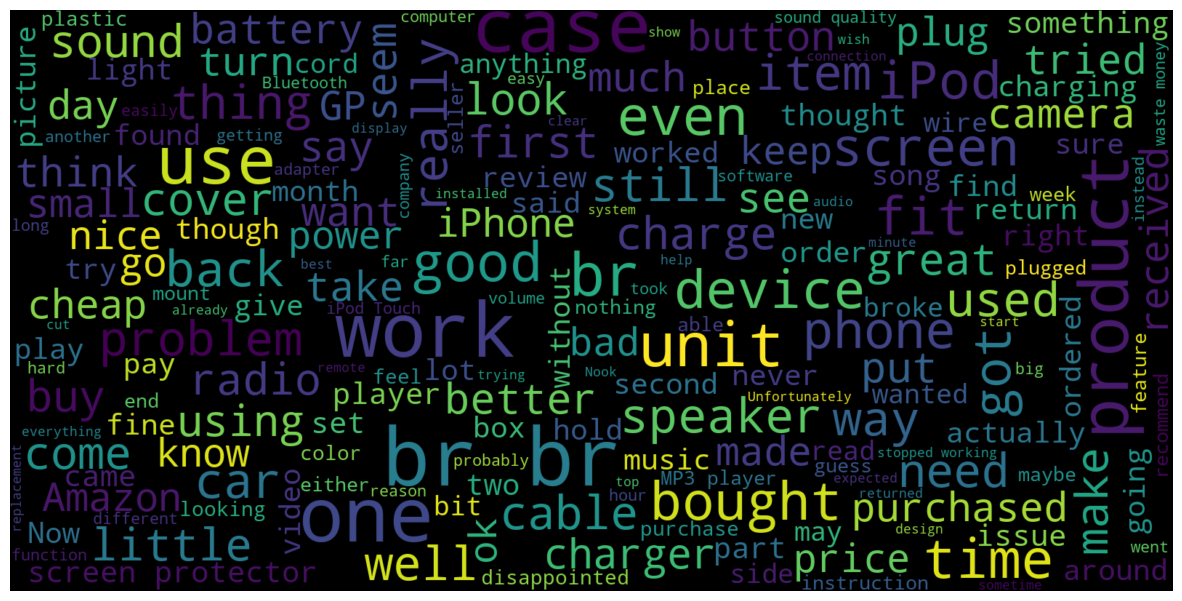

In [15]:
consolidated=' '.join(word for word in data['Review'][data['Sentiment']==0].astype(str))
wordCloud=WordCloud(width=1600,height=800,random_state=21,max_font_size=110)
plt.figure(figsize=(15,10))
plt.imshow(wordCloud.generate(consolidated),interpolation='bilinear')
plt.axis('off')
plt.show()

Let's do the same for all the words with sentiment = 1 i.e. positive

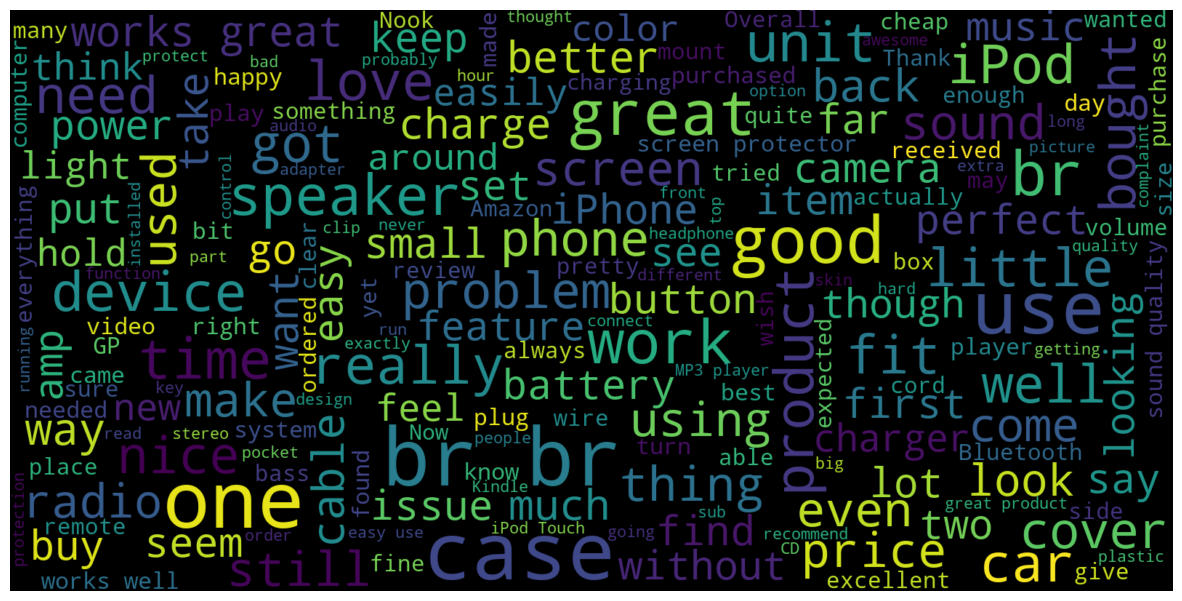

In [16]:
consolidated=' '.join(word for word in data['Review'][data['Sentiment']==1].astype(str))
wordCloud=WordCloud(width=1600,height=800,random_state=21,max_font_size=110)
plt.figure(figsize=(15,10))
plt.imshow(wordCloud.generate(consolidated),interpolation='bilinear')
plt.axis('off')
plt.show()

Now we have a clear picture of the words we have in both the categories.

Let's create the vectors.

## Converting text into Vectors

TF-IDF calculates that how relevant a word in a series or corpus is to a text. The meaning increases proportionally to the number of times in the text a word appears but is compensated by the word frequency in the corpus (data-set). We will be implementing this with the code below.

In [18]:
cv = TfidfVectorizer(max_features=2500)
X = cv.fit_transform(data['Review'] ).toarray()

## Model training, Evaluation, and Prediction

Once analysis and vectorization is done. We can now explore any machine learning model to train the data. But before that perform the train-test split.

In [19]:
from sklearn.model_selection import train_test_split
x_train ,x_test,y_train,y_test=train_test_split(X,data['Sentiment'],
                                                test_size=0.25 ,
                                                random_state=42)

Now we can train any model, Let's explore the Logistic Regression.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression()

#Model fitting
model.fit(x_train,y_train)

#testing the model
pred=model.predict(x_test)

#model accuracy
print(accuracy_score(y_test,pred))

# This code is modified by Susobhan Akhuli

0.81424


Let's see the confusion matrix for the results.

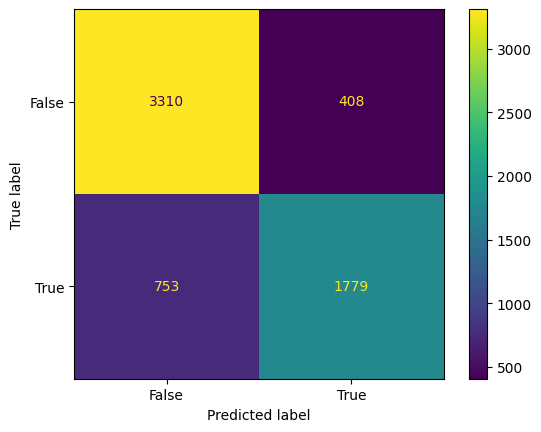

In [21]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, 
                                            display_labels = [False, True])

cm_display.plot()
plt.show()

# This code is modified by Susobhan Akhuli